# Import library

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import math
# from . import calc_util as cu
import sys
sys.path.append('src')
import dhw_ex_model as dem
import dartwork_mpl as dm
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.ticker as ticker
dm.use_dmpl_style()


Load colors...
Load colormaps...


# 0. Fontsize 지정

In [3]:
plt.rcParams['font.size'] = 9

fs = {
    'label': dm.fs(0),
    'tick': dm.fs(-0.5),
    'legend': dm.fs(-2.0),
    'subtitle': dm.fs(-0.5),
    'cbar_tick': dm.fs(-2.0),
    'cbar_label': dm.fs(-2.0),
    'cbar_title': dm.fs(-1),
    'setpoint': dm.fs(-1),
    'text': dm.fs(-3.0),
            }

pad = {
    'label': 6,
    'tick': 5,
}

LW = np.arange(0.25, 3.0, 0.25)

## 1.1 Constant

In [4]:
c_w = 4186  # J/kgK
rho_w = 1000  # kg/m3

# 2. Function

In [9]:
# =============================================================================
# 5) (옵션) 플롯 시작부
#    - 한글 폰트 설정 등은 사용 OS 환경에 맞게 수동 설정
# =============================================================================
def plot_simple_graph(df_column, time, xlabel, ylabel, xmin = 0, xmax=24, Kelvin=False, color = 'dm.blue5', savepath = None):
    # 온도 데이터를 섭씨(°C)로 변환하여 플로팅
    if Kelvin:
        y = dem.K2C(df_column)
    else:
        y = df_column
    x = time * dem.s2h  # 초를 시간으로 변환

    fig, ax = plt.subplots(figsize=(dm.cm2in(16), dm.cm2in(6)))
    
    # --- 마이너 틱 설정 ---

    # X축: 주 틱 사이를 5개의 간격으로 나눔 (마이너 틱 4개 생성)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))

    # Y축: 주 틱 사이를 2개의 간격으로 나눔 (마이너 틱 1개 생성)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))

    ax.plot(x, y, color=color, linewidth=0.5,)
    ax.set_xlim(xmin, xmax)
    if xmax % 24 == 0: 
        if xmax == 24:
            ax.set_xticks(np.arange(0, 25, 2))
        elif xmax == 48:
            ax.set_xticks(np.arange(0, xmax+1, 6))
        elif xmax == 72:
            ax.set_xticks(np.arange(0, xmax+1, 12))
        elif xmax > 72:
            ax.set_xticks(np.arange(0, xmax+1, 24))

    ax.tick_params(axis='both', which='both', labelsize=fs['tick'], pad=pad['tick'])
    ax.set_ylim(np.nanmin(y)*0.9, np.nanmax(y)*1.1)
    # ax.set_ylim(50, 55)
    ax.set_xlabel(xlabel, fontsize=fs['label'], labelpad=pad['label'])
    ax.set_ylabel(ylabel, fontsize=fs['label'], labelpad=pad['label'])
    dm.simple_layout(fig, margins=(0.05, 0.05, 0.05, 0.05), bbox = [0, 1, 0.02, 1])
    plt.savefig(f'{savepath}.png')
    dm.save_and_show(fig,)
    plt.close()

def plot_multi_graph(df_columns, legends, time, xlabel, ylabel, linestyles=None, colors=None,
                     xmin=0, xmax=24, Kelvin=False, savepath=None, scatter=False,
                     logx=False, logy=False, leg_ncol=10):
    """
    여러 개의 데이터 열을 받아 하나의 그래프에 플로팅하는 함수.
    scatter=True이면 점 그래프(scatter plot)를 그립니다.

    Args:
        *df_columns: 플로팅할 데이터 열들 (예: df['col1'], df['col2'], ...)
        legends (list or tuple): 각 데이터 열에 해당하는 레이블 리스트
        time (array-like): x축 시간 데이터 [s]
        colors (list or tuple, optional): 각 플롯에 사용할 색상 리스트
        scatter (bool): True이면 scatter plot, False이면 line plot
        logx (bool): x축 로그 스케일 사용 여부
        logy (bool): y축 로그 스케일 사용 여부
    """
    if len(df_columns) != len(legends):
        raise ValueError("데이터 컬럼의 개수와 레이블의 개수가 일치해야 합니다.")

    if logx and xmin <= 0:
        raise ValueError("logx=True에서는 xmin > 0 이어야 합니다.")

    fig, ax = plt.subplots(figsize=(dm.cm2in(16), dm.cm2in(6)))
    x = time * dem.s2h  # 초 -> 시간

    # 색상 기본값
    if colors is None:
        colors = ['dm.blue5', 'dm.orange5', 'dm.green5', 'dm.red5', 'dm.violet5',
                  'dm.gray5', 'dm.yellow5', 'dm.cyan5']

    # 축 범위
    ax.set_xlim(xmin, xmax)

    # 선형축 전용 xticks (로그일 때는 건너뜀)
    if not logx and (xmax % 24 == 0):
        if xmax == 24:
            ax.set_xticks(np.arange(0, 25, 2))
        elif xmax == 48:
            ax.set_xticks(np.arange(0, xmax+1, 6))
        elif xmax == 72:
            ax.set_xticks(np.arange(0, xmax+1, 12))
        elif xmax > 72:
            ax.set_xticks(np.arange(0, xmax+1, 24))

    # 구간 슬라이스
    xmin_idx = np.argmin(np.abs(time - xmin * dem.h2s))
    xmax_idx = np.argmin(np.abs(time - xmax * dem.h2s))

    processed_ys = []
    for col in df_columns:
        y = dem.K2C(col) if Kelvin else col
        y_seg = y[xmin_idx:xmax_idx+1]
        if logy:
            # 로그축: 비양수 값은 표시 불가 → NaN으로 마스킹
            y_seg = np.where(y_seg > 0, y_seg, np.nan)
        processed_ys.append(y_seg)

    # x 슬라이스 및 로그 x축 유효성
    x = x[xmin_idx:xmax_idx+1]
    if logx:
        # 로그축: 비양수 x는 허용되지 않음
        if np.any(x <= 0):
            raise ValueError("logx=True에서는 선택된 구간의 모든 x가 > 0 이어야 합니다.")
        ax.set_xscale('log')

    # 플로팅
    for i, y_data in enumerate(processed_ys):
        current_color = colors[i % len(colors)]
        current_label = legends[i]
        if scatter:
            ax.scatter(x, y_data, color=current_color, label=current_label, s=1.5, alpha=0.3)
        else:
            current_linestyle = linestyles[i % len(linestyles)] if linestyles is not None else ['-', '--', '-.', ':'][i % 4]
            ax.plot(x, y_data, color=current_color, linewidth=0.8, label=current_label, linestyle=current_linestyle)

    # 마이너 틱: 선형축에만 적용
    if not logx:
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    if not logy:
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))

    # y축 범위와 스케일
    if logy:
        ax.set_yscale('log')
        # 로그축용 안전한 ylim 계산 (양수만 고려)
        y_min = np.nanmin([arr for arr in processed_ys])
        y_max = np.nanmax([arr for arr in processed_ys])
        if not np.isfinite(y_min) or not np.isfinite(y_max):
            ax.set_ylim(1.0, 10.0)  # fallback
        else:
            ax.set_ylim(y_min*np.power(10, -0.05), y_max*np.power(10, 0.05))  # 살짝 여유
    else:
        y_min = np.nanmin([processed_ys[i] for i in range(len(processed_ys))])
        y_max = np.nanmax([processed_ys[i] for i in range(len(processed_ys))])
        global_int = y_max - y_min
        if np.isinf(y_min) or np.isinf(y_max):
            ax.set_ylim(0, 1)
        else:
            ax.set_ylim(y_min - global_int * 0.1, y_max + global_int * 0.3)

    ax.tick_params(axis='both', which='both', labelsize=fs['tick'], pad=pad['tick'])
    ax.set_xlabel(xlabel, fontsize=fs['label'], labelpad=pad['label'])
    ax.set_ylabel(ylabel, fontsize=fs['label'], labelpad=pad['label'])
    ax.legend(ncol=leg_ncol, fontsize=fs['legend'])
    dm.simple_layout(fig, margins=(0.05, 0.05, 0.05, 0.05), bbox=[0, 1, 0.02, 1])

    if savepath:
        plt.savefig(f'{savepath}.png')
    dm.save_and_show(fig)
    plt.close()

# 3. System and schedule setting 

## 3.1 System define

In [28]:
# --- 1. 시뮬레이션 설정 ---
H = 0.8; D = 0.4; N = 10 # --> 약 100 L 탱크
tank = dem.StratifiedTankTDMA(r0=D/2, x_shell=0.005, x_ins=0.05, k_shell=50, k_ins=0.04, H=H, N=N, h_w=10, h_o=5, C_d_mix=0.01)

dt = 5 # 시간 간격 (60초 = 1분)
sim_hours = 24
n_steps = int(sim_hours * dem.h2s / dt) + 1
t_span = np.arange(n_steps) * dt # 시간 배열 [초]

T_initial_C = 40.0  # 초기 탱크 온도 [°C]
T_in_C      = 15.0  # 유입수 온도 [°C]
T0_C        = 20.0  # 초기 외기 온도 [°C]

heater_capacity = 3000  # 히터 전력 [W]
heater_node     = 5  # 히터 위치

thermostat_on_C  = 50.0  # 서모스탯 켜짐 온도 [°C]
thermostat_off_C = 60.0  # 서모스탯 꺼짐 온도 [°C]

# Loop ################################################################
# loop_outlet_node = 10  # 탱크 하부에서 빼서
# loop_inlet_node  = 1   # 상부로 되돌림 (하향 경로)

# LITER_PER_MIN_TO_M3_PER_SEC = 1/60000
# dV_loop = 2.5*LITER_PER_MIN_TO_M3_PER_SEC   # [m^3/s] = 2.5 L/min 정도 예시
# Q_loop  = 100 - 500 * np.cos(2 * np.pi * t_span / (24 * dem.h2s))
# Q_loop = np.clip(Q_loop, 0, None)   # 하한 0, 상한 제한 없음

## 3.2 Schedule setting

- TO DO: 스케줄을 보다 유연하게 설정할 수 있는 구조가 필요함, GSHPB의 구조와 통일되어야함

In [29]:
# --- 2. 24시간 가상 스케줄 생성 ---
# 외기 온도 스케줄 (15°C ~ 25°C 사이에서 변동)
T_amb_C = 20
T_amb_K = dem.C2K(T_amb_C)

# 온수 사용량(dV) 스케줄 [m³/s]
# 아침(7-9시), 저녁(19-21시)에 각 60리터 사용 가정
dV_schedule = np.zeros(n_steps)
morning_usage_L   = 100
evening_usage_L   = 100
morning_start_idx = int(7 * dem.h2s / dt)
morning_end_idx   = int(8 * dem.h2s / dt)
evening_start_idx = int(19 * dem.h2s / dt)
evening_end_idx   = int(20 * dem.h2s / dt)

# 사용 시간에 걸쳐 유량 균등 분배
dV_schedule[morning_start_idx:morning_end_idx] = (morning_usage_L * dem.L2m3) / (morning_end_idx - morning_start_idx) / dt # 단위: m³/s
dV_schedule[evening_start_idx:evening_end_idx] = (evening_usage_L * dem.L2m3) / (evening_end_idx - evening_start_idx) / dt # 단위: m³/s


## 3.3 시뮬레이션 실행

In [40]:
# 결과 저장을 위한 배열 초기화
results = {k: np.empty((n_steps-1, N), dtype=np.float32) for k in [
    'T','Q_loss','Q_heater','Q_st','Q_w_use_in','Q_w_use_out', 'Q_w_mix_in','Q_w_mix_out','Q_cond_in','Q_cond_out',
    'Xc','X_loss','X_heater','X_st','X_w_use_in','X_w_use_out','X_w_mix_in','X_w_mix_out','X_cond_in','X_cond_out'
]}
# k_eff는 노드 쌍(i, i+1) 사이의 값이므로 shape가 (n_steps-1, N-1)입니다
results['k_eff'] = np.empty((n_steps-1, N-1), dtype=np.float32)

heater_on = False # 히터 초기 상태
T_old_K = np.full(N, dem.C2K(T_initial_C)) # 초기 온도를 Kelvin으로 설정

# G_use = []
# dV_mix = []
# 시뮬레이션 루프 
for n in tqdm(range(n_steps)):

    Q_w_use_in_arr     = np.zeros(N)
    Q_w_use_out_arr    = np.zeros(N)
    Q_w_mix_in_arr     = np.zeros(N)
    Q_w_mix_out_arr    = np.zeros(N)
    Q_tank_storage_arr = np.zeros(N)
    Q_cond_in_arr      = np.zeros(N)
    Q_cond_out_arr     = np.zeros(N)
    Q_heater_arr       = np.zeros(N)
    Q_loss_arr         = np.zeros(N)
    
    X_w_use_in_arr     = np.zeros(N)
    X_w_use_out_arr    = np.zeros(N)
    # X_w_mix_in_arr     = np.zeros(N)
    # X_w_mix_out_arr    = np.zeros(N)
    X_tank_storage_arr = np.zeros(N)
    X_cond_in_arr      = np.zeros(N)
    X_cond_out_arr     = np.zeros(N)
    X_heater_arr       = np.zeros(N)
    Xc_arr             = np.zeros(N)
    
    # 히터 제어
    heater_sensor_temp_C = dem.K2C(T_old_K[heater_node-1])
    if heater_sensor_temp_C > thermostat_off_C:
        heater_on = False
    # 2. 켜지는 조건: On 온도보다 낮아지면 켠다.
    elif heater_sensor_temp_C < thermostat_on_C:
        heater_on = True
    current_heater_W = heater_capacity if heater_on else 0.0
    Q_heater_arr[heater_node-1] = current_heater_W
    # print('heater_on:', heater_on, ' at node ', heater_node_arr)
    
    # 다음 타임스텝 온도 계산
    T_new_K = tank.update_tank_temp(
        T=T_old_K,
        dt=dt,
        T_in=dem.C2K(T_in_C),
        dV_use=dV_schedule[n],
        T_amb=T_amb_K,
        T0=dem.C2K(T0_C),
        heater_node=heater_node,
        heater_capacity=current_heater_W,
        # ---- 루프 추가 인자 ----
        # loop_outlet_node=loop_outlet_node,
        # loop_inlet_node=loop_inlet_node,
        # dV_loop=dV_loop,
        # Q_loop=Q_loop[n]
    )
    
    if n >= 1:

        Q_cond_in_arr[:-1] = tank.K * (T_new_K[1:] - T_new_K[:-1]) # Q_cond_in_arr[-1] = 0, Q_cond_in_arr[1] = K*(T_1 - T_0)
        Q_cond_out_arr[1:] = tank.K * (T_new_K[1:] - T_new_K[:-1]) # Q_cond_out_arr[0] = 0, Q_cond_out_arr[-2] = K*(T_N-1 - T_N-2)
        
        for i in range(N-1): 
            Q_w_use_out_arr[i] = tank.G_use * (T_new_K[i] - tank.T0)
            Q_w_use_in_arr[i]  = tank.G_use * (T_new_K[i+1] - tank.T0)
            # Q_w_mix_out_arr[i] = tank.G_mix[i] * (T_new_K[i] - tank.T0)
            # Q_w_mix_in_arr[i]  = tank.G_mix[i] * (T_new_K[i+1] - tank.T0)

        Q_w_use_out_arr[N-1] = tank.G_use * (T_new_K[N-1] - tank.T0)  
        Q_w_use_in_arr[N-1]  = tank.G_use * (dem.C2K(T_in_C) - tank.T0)
        Q_w_mix_out_arr[N-1] = 0
        Q_w_mix_in_arr[N-1]  = 0
        
        Q_loss_arr = tank.UA * (T_new_K - T_amb_K)

        Q_tank_storage_arr = tank.C * tank.V * (T_new_K - T_old_K) / dt

        X_heater_arr = (1-tank.T0/float('inf')) * Q_heater_arr

        # dV_mix_max = np.max(tank.G_mix / (c_w * rho_w))  # 체적 유량으로 변환
        # dV_mix.append(dV_mix_max)

        for i in range(N-1): 
            X_w_use_out_arr[i] = dem.calc_exergy_flow(G=tank.G_use, T = T_new_K[i], T0=tank.T0)
            X_w_use_in_arr[i]  = dem.calc_exergy_flow(G=tank.G_use, T = T_new_K[i+1], T0=tank.T0)
            # X_w_mix_out_arr[i] = dem.calc_exergy_flow(G=tank.G_mix[i], T = T_new_K[i], T0=tank.T0)
            # X_w_mix_in_arr[i]  = dem.calc_exergy_flow(G=tank.G_mix[i], T = T_new_K[i+1], T0=tank.T0)

        X_w_use_out_arr[N-1] = dem.calc_exergy_flow(G=tank.G_use, T = T_new_K[N-1], T0=tank.T0)
        X_w_use_in_arr[N-1]  = dem.calc_exergy_flow(G=tank.G_use, T = dem.C2K(T_in_C), T0=tank.T0)
        # X_w_mix_out_arr[N-1] = 0
        # X_w_mix_in_arr[N-1]  = 0
        
        X_cond_in_arr = (1 - tank.T0 / T_new_K) * Q_cond_in_arr
        X_cond_out_arr = (1 - tank.T0 / T_new_K) * Q_cond_out_arr
        
        X_tank_storage_arr = (1 - tank.T0 / T_old_K) * Q_tank_storage_arr

        X_loss_arr = (1 - tank.T0 / T_amb_K) * Q_loss_arr

        for i in range(N):
            Xc_arr[i]  = 0.0
            Xc_arr[i] += X_heater_arr[i]
            Xc_arr[i] += X_w_use_in_arr[i]  - X_w_use_out_arr[i]
            # Xc_arr[i] += X_w_mix_in_arr[i]  - X_w_mix_out_arr[i]
            Xc_arr[i] += X_cond_in_arr[i]   - X_cond_out_arr[i]
            Xc_arr[i] -= X_tank_storage_arr[i] + X_loss_arr[i]
        
        # Exergy calculation:
        results['T'][n-1,:]           = T_new_K
        results['Q_loss'][n-1,:]      = Q_loss_arr
        results['Q_heater'][n-1,:]    = Q_heater_arr
        results['Q_st'][n-1,:]        = Q_tank_storage_arr
        results['Q_w_use_in'][n-1,:]  = Q_w_use_in_arr
        results['Q_w_use_out'][n-1,:] = Q_w_use_out_arr
        results['Q_w_mix_in'][n-1,:]  = Q_w_mix_in_arr
        results['Q_w_mix_out'][n-1,:] = Q_w_mix_out_arr
        results['Q_cond_in'][n-1,:]   = Q_cond_in_arr
        results['Q_cond_out'][n-1,:]  = Q_cond_out_arr
        
        results['Xc'][n-1,:]          = Xc_arr
        results['X_loss'][n-1,:]      = X_loss_arr
        results['X_heater'][n-1,:]    = X_heater_arr
        results['X_st'][n-1,:]        = X_tank_storage_arr
        results['X_w_use_in'][n-1,:]  = X_w_use_in_arr
        results['X_w_use_out'][n-1,:] = X_w_use_out_arr
        # results['X_w_mix_in'][n-1,:]  = X_w_mix_in_arr
        # results['X_w_mix_out'][n-1,:] = X_w_mix_out_arr
        results['X_cond_in'][n-1,:]   = X_cond_in_arr
        results['X_cond_out'][n-1,:]  = X_cond_out_arr
        
        # 유효 열전도율 저장 (노드 쌍(i, i+1) 사이의 값)
        results['k_eff'][n-1, :] = tank.k_eff
        
        T_old_K = T_new_K.copy()

100%|██████████| 17281/17281 [00:01<00:00, 16131.54it/s]


In [41]:
t_plot = t_span[:-1]
# 유효 열전도율 (k_eff) 시각화
# 각 레이어 사이(i, i+1)의 k_eff 변화를 시간에 따라 표시
layer_pairs = [i for i in range(N-1)]  # 0부터 N-2까지 (총 N-1개 레이어 쌍)
k_eff_cols = [results['k_eff'][:, i] for i in layer_pairs]
k_eff_legs = [f'Layer {i+1}-{i+2}' for i in layer_pairs]  # Node i+1과 Node i+2 사이

plot_multi_graph(
    k_eff_cols, 
    k_eff_legs, 
    t_plot, 
    'Time [h]', 
    'Effective thermal cond [W/m·K]', 
    Kelvin=False, 
    xmin=0, 
    xmax=24, 
    savepath='figure/k_eff_all_layers',
    leg_ncol=min(5, N-1)
)

# 특정 시간 구간 확대 (예: 히터 작동 구간)
plot_multi_graph(
    k_eff_cols, 
    k_eff_legs, 
    t_plot, 
    'Time [h]', 
    'Effective thermal cond [W/m·K]', 
    Kelvin=False, 
    xmin=2, 
    xmax=4, 
    savepath='figure/k_eff_zoom',
    leg_ncol=min(5, N-1)
)


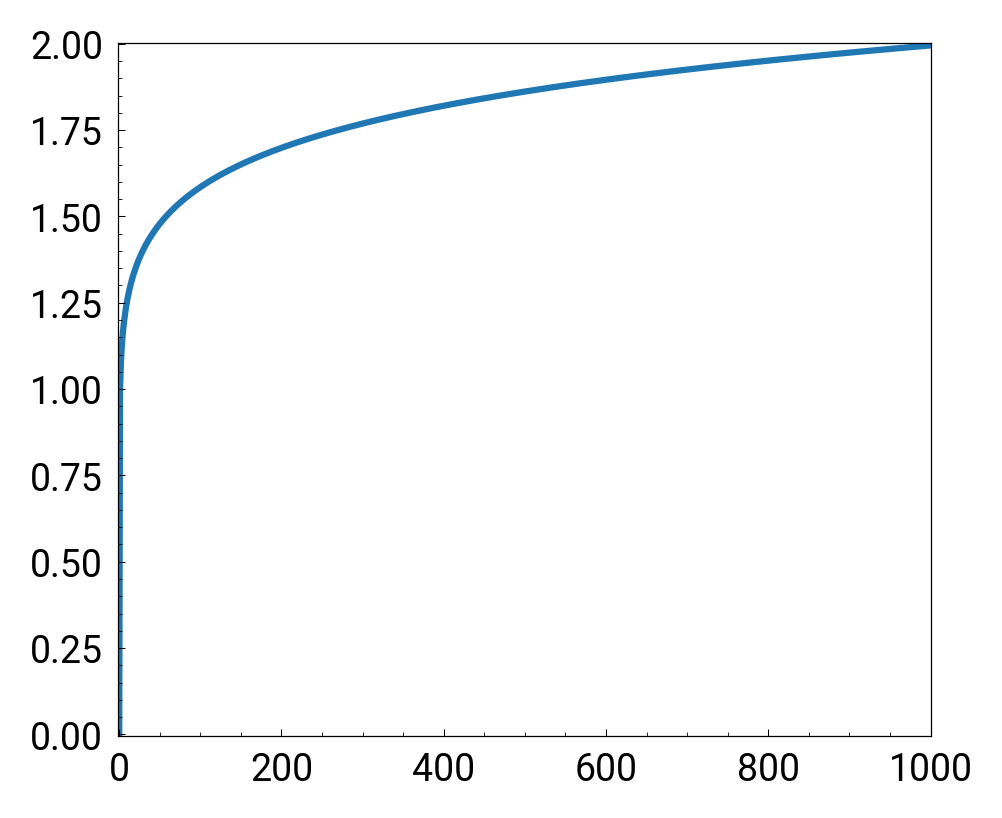

In [45]:
X = np.arange(1000)
Y = X**(0.1)
plt.plot(X,Y)

In [39]:
# ...existing code...
# 시각화 예제들 (t_span[:-1] 길이 == results['...'].shape[0] 이어야 함)

t_plot = t_span[:-1]     # 결과가 n_steps-1 길이로 저장된 경우
t_hours = t_plot * dem.s2h

# 1) 탱크 상위 노드(예: Node 1-4) 온도 (Kelvin->C 변환)
node_idxs = [0,3,4,7,9]  # 0-based indices
node_idxs = [i for i in range(N)]  # 모든 노드
cols = [results['T'][:, i] for i in node_idxs] + [np.array([dem.C2K(T0_C) for _ in range(len(t_plot))])] + [np.array([dem.C2K(T_in_C) for _ in range(len(t_plot))])]
legs = [f'Node {i+1}' for i in node_idxs] + ['Environment'] + ['Supply city water']
plot_multi_graph(cols, legs, t_plot, 'Time [h]', 'Temperature [°C]', Kelvin=True, xmin=0, xmax=24, savepath='figure/temp', leg_ncol=6,)

# # # 2) 노드별 잔류 엑서지 Xc(예: 바닥 노드)
# cols = [results['Xc'][:, i] for i in node_idxs]
# legs = [f'Node {i+1}' for i in node_idxs]
# plot_multi_graph(cols, legs, t_plot, 'Time [h]', 'Exergy consumption rate [W]', Kelvin=False, xmin=0, xmax=24, savepath='figure/Xc4')  # colors = ['dm.orange5', 'dm.green5', 'dm.red5'], linestyles = ['--', '-.', ':'], )

# cols = [results['Xc'][:, i] for i in node_idxs]
# legs = [f'Node {i+1}' for i in node_idxs]
# plot_multi_graph(cols, legs, t_plot, 'Time [h]', 'Exergy consumption rate [W]', Kelvin=False, xmin=18.8, xmax=20.2, savepath='figure/Xc3',  )


# # # 3) 전체 손실/히터 엑서지 합계 비교
# cols  = [results['X_loss'][:, i] for i in node_idxs]
# legs  = [f'Node {i+1}' for i in node_idxs]
# plot_multi_graph(cols, legs, t_plot, 'Time [h]', 'Exergy loss [W]', Kelvin=False, xmin=0, xmax=24, savepath='figure/exergy_loss')    

# cols = [results['Q_loss'][:, i] for i in node_idxs]
# legs = [f'Node {i+1}' for i in node_idxs]
# plot_multi_graph(cols, legs, t_plot, 'Time [h]', 'Heat loss [W]', Kelvin=False, xmin=0, xmax=24, savepath='figure/heat_loss')

# # 4) 유입/유출 물의 엑서지(예시: 상위 3개 노드)
# cols = [results['X_tank_w_in'][:, i] for i in node_idxs]
# legs = [f'Node {i+1}' for i in node_idxs]
# plot_multi_graph(cols, legs, t_plot, 'Time [h]', 'Exergy inflow by water use [W]', Kelvin=False, xmin=0.0, xmax=24, savepath='figure/tank_w_in')

# cols = [results['X_tank_w_out'][:, i] for i in node_idxs]
# legs = [f'Node {i+1}' for i in node_idxs]
# plot_multi_graph(cols, legs, t_plot, 'Time [h]', 'Exergy outflow by water use [W]', Kelvin=False, xmin=0.0, xmax=24, savepath='figure/tank_w_out')

# cols = [results['Q_cond_in'][:, i] for i in node_idxs]
# legs = [f'Node {i+1}' for i in node_idxs]
# plot_multi_graph(cols, legs, t_plot, 'Time [h]', 'Heat conduction inflow [W]', Kelvin=False, xmin=0, xmax=24, savepath='figure/cond_in')


# cols = [results['Q_cond_out'][:, i] for i in node_idxs]
# legs = [f'Node {i+1}' for i in node_idxs]
# plot_multi_graph(cols, legs, t_plot, 'Time [h]', 'Heat conduction outflow [W]', Kelvin=False, xmin=0, xmax=24, savepath='figure/cond_out')

# 저장을 원치 않으면 savepath 인자를 제거하거나 None으로 설정하세요.
# ...existing code...

In [33]:
0.2*10**3**0.25

4.14098834932834

In [34]:
len(results['Q_heater'][:,0]) + len(results['Q_heater'][:,1])

34560

In [35]:
for i in node_idxs:
    cols = [results['Q_heater'][:,i]] + [results['Q_w_use_in'][:,i]] + [results['Q_w_use_out'][:,i]] + [results['Q_w_mix_in'][:,i]] + [results['Q_w_mix_out'][:,i]] + [results['Q_st'][:,i]] + [results['Q_cond_in'][:,i]] + [results['Q_cond_out'][:,i]] + [results['Q_loss'][:,i]]
    
    legs = [
        'heater',
        'w_use_in',
        'w_use_out',
        'w_mix_in',
        'w_mix_out',
        'tank_storage',
        'cond_in',
        'cond_out',
        'loss'
        ]
    plot_multi_graph(cols, legs, t_plot, 'Time [h]', f'Energy subterm of node {i+1} [W]', Kelvin=False, xmin=6.8, xmax=8.2, leg_ncol= 5)

KeyboardInterrupt: 

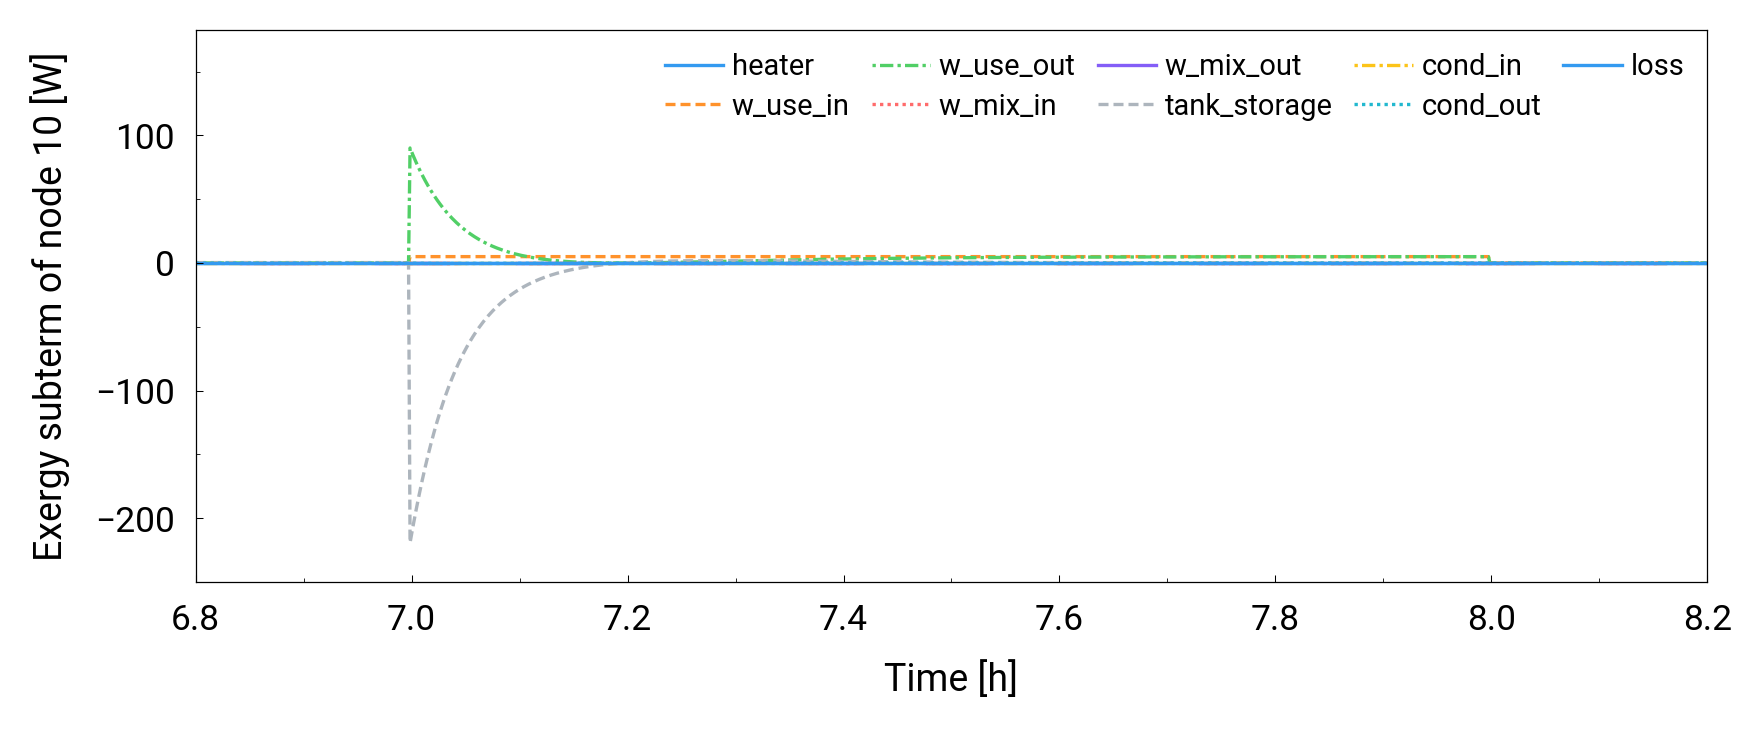

In [36]:
for i in node_idxs:
# for i in [1]:
    cols = [results['X_heater'][:,i]] + [results['X_w_use_in'][:,i]] + [results['X_w_use_out'][:,i]]  + [results['X_w_mix_in'][:,i]] + [results['X_w_mix_out'][:,i]] + [results['X_st'][:,i]] + [results['X_cond_in'][:,i]] + [results['X_cond_out'][:,i]] + [results['X_loss'][:,i]]
    legs = ['heater', 'w_use_in', 'w_use_out', 'w_mix_in', 'w_mix_out', 'tank_storage', 'cond_in', 'cond_out', 'loss']
    plot_multi_graph(cols, legs, t_plot, 'Time [h]', f'Exergy subterm of node {i+1} [W]', Kelvin=False, xmin=6.8, xmax=8.2, savepath=f'figure/exergy_subterms_node_{i+1}', leg_ncol=5)
    plot_multi_graph([results['Xc'][:,i]], [f'Exergy consumption rate of node {i+1}'], t_plot, 'Time [h]', f'Exergy consum of node {i+1} [W]', Kelvin=False, xmin=0, xmax=24, savepath=f'figure/exergy_consum_node_{i+1}')

In [ ]:
cols = [results['Xc'][:, i] for i in node_idxs]
legs = [f'Node {i+1}' for i in node_idxs]
plot_multi_graph(cols, legs, t_plot, 'T3ime [h]', 'Exergy consumption rate [W]', Kelvin=False, xmin=6.8, xmax=8.2,)

Global min: -132.29144931668696, Global max: 199.04606545247645


In [ ]:
for i in node_idxs:
    cols = [results['X_heater'][:,i]] + [results['X_tank_w_in'][:,i]] + [results['X_tank_w_out'][:,i]] + [results['X_st'][:,i]] + [results['X_cond_in'][:,i]] + [results['X_cond_out'][:,i]] + [results['X_loss'][:,i]]
    legs = ['heater', 'tank_w_in', 'tank_w_out', 'tank_storage', 'cond_in', 'cond_out', 'loss']
    plot_multi_graph(cols, legs, t_plot, 'Time [h]', f'Exergy subterm of node {i+1} [W]', Kelvin=False, xmin=6.8, xmax=8.2, savepath='figure/sub_ex_node'+str(i+1))

array([3000.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
          0.])

In [ ]:
X_heater_arr[i] + X_tank_w_in_arr[i-1] - X_tank_w_out_arr[i-1] - X_tank_storage_arr[i] + X_cond_in_arr[i-1] - X_cond_out_arr[i-1] - X_loss_arr[i]

# Test

In [14]:
#%% 시뮬레이션 및 결과 시각화
'''
24시간 운전 시나리오
가상 시나리오는 다음과 같이 설정

초기 상태: 탱크의 모든 노드는 40°C로 균일하게 시작합니다.
외기 온도: 하루 동안 15°C에서 25°C 사이를 부드럽게 변동합니다.
온수 사용: 아침(7-8시)과 저녁(19-20시)에 집중적으로 온수를 사용합니다.
내부 히터: 탱크 하부(Node 10)에 히터가 설치되어 있으며, 이 노드의 온도가 50°C 아래로 떨어지면 작동하고 60°C 이상으로 올라가면 멈추는 자동온도조절기(Thermostat) 로직을 따릅니다.
급수 온도: 탱크로 유입되는 물의 온도는 15°C로 일정합니다.
'''

# --- 1. 시뮬레이션 설정 ---
H = 0.8; D = 0.4; N = 10 # --> 약 100 L 탱크
tank = dem.StratifiedTankTDMA(r0=D/2, x_shell=0.005, x_ins=0.05, k_shell=50, k_ins=0.04, H=H, N=N, h_w=10, h_o=5, C_d_mix=0.8,)

dt = 5 # 시간 간격 (60초 = 1분)
sim_hours = 24
n_steps = int(sim_hours * dem.h2s / dt)
t_span = np.arange(n_steps) * dt # 시간 배열 [초]

T_initial_C = 40.0 # 초기 탱크 온도 [°C]
T_in_C = 15.0 # 유입수 온도 [°C]

heater_power_W = 0 # 히터 전력 [W]
heater_node = 1 # 히터 위치

thermostat_on_C = 50.0 # 서모스탯 켜짐 온도 [°C]
thermostat_off_C = 60.0 # 서모스탯 꺼짐 온도 [°C]

loop_outlet_node = 10   # 탱크 하부에서 빼서
loop_inlet_node  = 1    # 상부로 되돌림 (하향 경로)

LITER_PER_MIN_TO_M3_PER_SEC = 1/60000
dV_loop = 2.5*LITER_PER_MIN_TO_M3_PER_SEC   # [m^3/s] = 2.5 L/min 정도 예시
Q_loop  = 100 - 500 * np.cos(2 * np.pi * t_span / (24 * dem.h2s))
Q_loop = np.clip(Q_loop, 0, None)   # 하한 0, 상한 제한 없음


# --- 2. 24시간 가상 스케줄 생성 ---
# 외기 온도 스케줄 (15°C ~ 25°C 사이에서 변동)
T_amb_C = 20 - 5 * np.cos(2 * np.pi * t_span / (24 * dem.h2s))
T_amb_K = dem.C2K(T_amb_C)

# 온수 사용량(dV) 스케줄 [m³/s]
# 아침(7-9시), 저녁(19-21시)에 각 100리터 사용 가정
dV_schedule = np.zeros(n_steps)
morning_usage_L = 100
evening_usage_L = 100
morning_start_idx = int(7 * dem.h2s / dt)
morning_end_idx = int(8 * dem.h2s / dt)
evening_start_idx = int(19 * dem.h2s / dt)
evening_end_idx = int(20 * dem.h2s / dt)

# 사용 시간에 걸쳐 유량 균등 분배
dV_schedule[morning_start_idx:morning_end_idx] = (morning_usage_L * dem.L2m3) / (morning_end_idx - morning_start_idx) / dt # 단위: m³/s
dV_schedule[evening_start_idx:evening_end_idx] = (evening_usage_L * dem.L2m3) / (evening_end_idx - evening_start_idx) / dt # 단위: m³/s


# --- 3. 시뮬레이션 실행 ---
# 결과 저장을 위한 배열 초기화
T_results = np.zeros((n_steps, N))
T_now = np.full(N, dem.C2K(T_initial_C)) # 초기 온도를 Kelvin으로 설정

heater_on = False # 히터 초기 상태
for k in range(n_steps):
    # 히터 제어 (기존 로직 유지)
    heater_sensor_temp_C = dem.K2C(T_now[heater_node-1])
    heater_on = (heater_sensor_temp_C < thermostat_on_C)
    if heater_sensor_temp_C > thermostat_off_C:
        heater_on = False
    current_heater_W = heater_power_W if heater_on else 0.0

    T_next = tank.update_tank_temp(
        T=T_now,
        dt=dt,
        T_in=dem.C2K(T_in_C),
        dV_use=dV_schedule[k],           # 기존 급탕 사용 유량
        T_amb=T_amb_K[k],
        heater_node=heater_node,
        heater_capacity=current_heater_W,
        # ---- 루프 추가 인자 ----
        loop_outlet_node=loop_outlet_node,
        loop_inlet_node=loop_inlet_node,
        dV_loop=dV_loop,
        Q_loop=Q_loop[k],
        T0 = dem.C2K(20.0)
    )
    T_results[k,:] = T_next
    T_now = T_next
tank.info()
# Visualization
# --- 4. 결과 시각화 ---
fig, axes = plt.subplots(2,1, figsize=(dm.cm2in(14), dm.cm2in(10)))
plt.subplots_adjust(hspace=0.4)
ax1 = axes[0]
ax2 = axes[1]

xmin1, xmax1, xint1, xmar1 = 0, sim_hours, 2, 0
ymin1, ymax1, yint1, ymar1 = 0, 80, 20, 0
ymin1_tw, ymax1_tw, yint1_tw, ymar1_tw = 0, 2, 0.5, 0
ymin2, ymax2, yint2, ymar2 = 0, 800, 200, 0


t_hours = t_span * dem.s2h
T_results_C = dem.K2C(T_results)

color_ax1_twin = 'dm.red'
cmap = plt.get_cmap('dm.Marine_r')
colors = [cmap(i) for i in np.linspace(0.1, 0.9, N)]


# 각 노드(성층)별 온도 변화 플로팅
for i in range(N):
    # 최상단(Node 1)은 굵게, 최하단(Node 10)은 점선으로 표시
    # if i == 0:
    #     ax1.plot(t_hours, T_results_C[:, i], label=f'$i = {i+1}$' + '(Top)', linewidth= LW[3], color=colors[i])
    # elif i == N - 1:
    #     ax1.plot(t_hours, T_results_C[:, i], label=f'$i = {i+1}$' + '(Bottom)', linewidth= LW[3], color=colors[i])
    if i == loop_inlet_node-1:
        ax1.plot(t_hours, T_results_C[:, i], label=f'$i = {i+1}$' + '(Loop in)', linewidth= LW[3], color=colors[i])
    elif i == loop_outlet_node-1:
        ax1.plot(t_hours, T_results_C[:, i], label=f'$i = {i+1}$' + '(Loop out)', linewidth= LW[3], color=colors[i])
    else:
        ax1.plot(t_hours, T_results_C[:, i], label=f'$i = {i+1}$', linewidth =LW[3], color=colors[i])

# 5) plot detail
ax1.set_xlabel('Elapsed Time [h]', fontsize=fs['label'], labelpad=pad['label'])
ax1.set_ylabel('Temperature [°C]', fontsize=fs['label'], labelpad=pad['label'])

ax1.set_xlim(xmin1 - xmar1, xmax1 + xmar1)
ax1.set_ylim(ymin1 - ymar1, ymax1 + ymar1)

# ax1.annotate(annotations, xy=(.01, 1.01), xycoords='axes fraction',
#     horizontalalignment='left', verticalalignment='bottom', fontsize=fs['annotation']) 

ax1.set_xticks(np.arange(xmin1, xmax1*1.001, xint1))
ax1.set_yticks(np.arange(ymin1, ymax1*1.001, yint1))

ax1.tick_params(labelsize=fs['tick'], which='major', length=2.5, width=0.3  , pad=pad['tick'])
ax1.tick_params(labelsize=fs['tick'], which='minor', length=1.25, width=0.3, pad=pad['tick'])

ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator(1))
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator(1))

handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles, labels, loc = 'upper center',fontsize=fs['legend'], bbox_to_anchor=(0.5, 1.1), ncols=5,
          handlelength = 1.5, columnspacing=2, labelspacing=0.5)


# 그래프 설정
ax1.set_xlabel('Elapsed time [h]', fontsize=fs['label'], labelpad=pad['label'])
ax1.set_ylabel('Temperature [°C]', fontsize=fs['label'], labelpad=pad['label'])
ax1.set_xticks(np.arange(0, 25, 2))

# 온수 사용 시점 시각적으로 표시
ax1_twin = ax1.twinx()
ax1_twin.fill_between(t_hours, 0, dV_schedule * dem.m32L / dem.s2m, color=color_ax1_twin + '4', alpha=0.3, label='Hot water use [L/min]')
ax1_twin.set_ylabel('Hot water usage [L/min]', fontsize=fs['label'], labelpad=pad['label'], color=color_ax1_twin + '6')

ax1_twin.set_ylim(0, ymax1_tw)

ax1_twin.set_yticks(np.arange(ymin1_tw, ymax1_tw*1.001, yint1_tw))
ax1_twin.spines['right'].set_visible(True)
ax1_twin.spines['right'].set_color(color_ax1_twin + '6')
ax1_twin.tick_params(axis='y', colors=color_ax1_twin + '6', labelsize=fs['tick'], which='major', pad=pad['tick'])

# 
ax2.plot(t_hours, Q_loop, color='dm.orange', linewidth=LW[3])
# 5) plot detail
ax2.set_xlabel('Elapsed time [h]', fontsize=fs['label'], labelpad=pad['label'])
ax2.set_ylabel('Solar heat gain [W]', fontsize=fs['label'], labelpad=pad['label'])

ax2.set_xlim(xmin1 - xmar1, xmax1 + xmar1)
ax2.set_ylim(ymin2 - ymar2, ymax2 + ymar2)

ax2.set_xticks(np.arange(xmin1, xmax1*1.001, xint1))
ax2.set_yticks(np.arange(ymin2, ymax2*1.001, yint2))

ax2.tick_params(labelsize=fs['tick'], which='major', length=2.5, width=0.3  , pad=pad['tick'])
ax2.tick_params(labelsize=fs['tick'], which='minor', length=1.25, width=0.3, pad=pad['tick'])

ax2.xaxis.set_minor_locator(ticker.AutoMinorLocator(1))
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator(1))

handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles, labels, loc = 'upper center',fontsize=fs['legend'], bbox_to_anchor=(0.5, 1.1), ncols=5,
          handlelength = 1.5, columnspacing=2, labelspacing=0.5)


dm.simple_layout(fig, bbox=[0, 1, 0, 1], margins=[0.05, 0.05, 0.05, 0.05])
# plt.savefig('figure/Tank_stratification_model/Tank_stratification_model_results(downward loop).png', dpi=300)
dm.save_and_show(fig)

=== StratifiedTankTDMA :: Model Info ===
[Geometry]
  H = 0.800 m,  D = 0.400 m,  A = 0.126 m²
  N = 10 layers,  dz = 0.080 m
  V_node = 0.010 m³,  V_total = 0.101 m³
[Thermal]
  C_node = 4.21e+04 J/K,  C_total = 4.21e+05 J/K
  K_axial (conduction) = 0.952 W/K
  UA_sum = 0.999 W/K  (min 0.075, max 0.201)
[Mixing]
  C_d_mix = 0.800
